# Predicción de Precios de Viviendas usando Random Forest (scikit-learn)


Este notebook te guía para entrenar un modelo Random Forest usando scikit-learn en el dataset de Precios de Viviendas.

El código se verá aproximadamente así:

```python
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

dataset = pd.read_csv("project/dataset.csv")
X = dataset.drop('SalePrice', axis=1)
y = dataset['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(model.score(X_test, y_test))
```

Random Forest (Bosque de Decisión) es una familia de modelos basados en árboles que incluye Random Forests y Gradient Boosted Trees. Son el mejor punto de salida cuando trabajas con datos tabulares.


## Importar librerías


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Comenta esto si las visualizaciones no funcionan en tu lado
%matplotlib inline

## Cargar el dataset


In [2]:
train_file_path = "train.csv"
dataset_df = pd.read_csv(train_file_path)
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (1460, 81)


Los datos están compuestos por 81 columnas y 1460 registros. Podemos ver las 81 dimensiones de nuestro dataset imprimiendo las primeras 3 entradas usando el siguiente código:

In [3]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


- Hay 79 columnas de características. Usando estas características, tu modelo tiene que predecir el precio de venta de la vivienda indicado por la columna etiqueta llamada `SalePrice`.


Eliminaremos la columna `Id` ya que no es necesaria para el entrenamiento del modelo.


In [4]:
dataset_df = dataset_df.drop('Id', axis=1)
dataset_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


Podemos inspeccionar los tipos de las columnas de características usando el siguiente código:


In [5]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

## Manejo de valores faltantes


In [ ]:
# Ver valores faltantes
missing_values = dataset_df.isnull().sum()
missing_values = missing_values[missing_values >
                                0].sort_values(ascending=False)
print("Columnas con valores faltantes:")
print(missing_values)

Columnas con valores faltantes:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Vamos a manejar los valores faltantes:

In [7]:
# Separar características y objetivo
X = dataset_df.drop('SalePrice', axis=1)
y = dataset_df['SalePrice']

# Identificar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas: {len(numeric_cols)}")
print(f"Columnas categóricas: {len(categorical_cols)}")

Columnas numéricas: 36
Columnas categóricas: 43


C:\Users\gusca\AppData\Local\Temp\ipykernel_1536\688840513.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [8]:
# Rellenar valores faltantes
# Para numéricos: usar la mediana
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Para categóricos: usar la moda
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Verificar que no hay valores faltantes
print(f"Valores faltantes restantes: {X.isnull().sum().sum()}")

Valores faltantes restantes: 0


## Codificar variables categóricas

In [9]:
# Usar Label Encoding para variables categóricas
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Dataset shape after encoding: {X.shape}")
X.head()

Dataset shape after encoding: (1460, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,0,3,3,0,4,...,0,0,2,2,2,0,2,2008,8,4
1,20,3,80.0,9600,1,0,3,3,0,2,...,0,0,2,2,2,0,5,2007,8,4
2,60,3,68.0,11250,1,0,0,3,0,4,...,0,0,2,2,2,0,9,2008,8,4
3,70,3,60.0,9550,1,0,0,3,0,0,...,0,0,2,2,2,0,2,2006,8,0
4,60,3,84.0,14260,1,0,0,3,0,2,...,0,0,2,2,2,0,12,2008,8,4


## División de datos


In [ ]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

print("{} examples in training, {} examples in testing.".format(
    len(X_train), len(X_test)))

1022 examples in training, 438 examples in testing.


## Distribución de Precios de Viviendas

Ahora echemos un vistazo a cómo se distribuyen los precios de las viviendas.


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


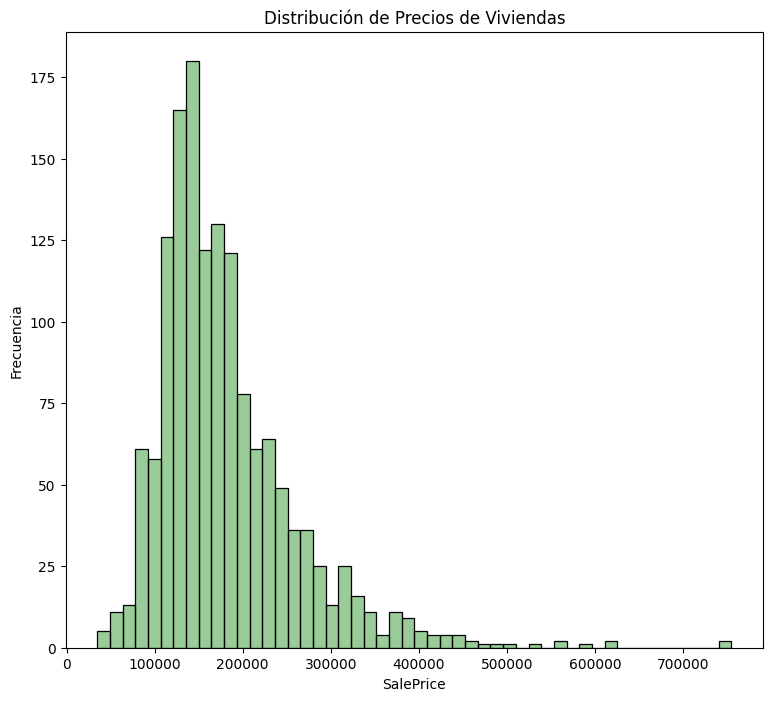

In [11]:
print(y.describe())
plt.figure(figsize=(9, 8))
sns.histplot(y, color='g', bins=50, alpha=0.4)
plt.title('Distribución de Precios de Viviendas')
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.show()

## Entrenar el modelo Random Forest

In [ ]:
# Crear y entrenar el modelo
rf_model = RandomForestRegressor(
    random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Modelo entrenado exitosamente!")

Modelo entrenado exitosamente!


## Predicciones y evaluación


In [14]:
# Predicciones
y_pred = rf_model.predict(X_test)

# Métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Métricas de Evaluación ===")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R2 Score: {r2:.4f}")

=== Métricas de Evaluación ===
MSE: 716,636,830.21
RMSE: 26,770.07
MAE: 16,861.23
R2 Score: 0.8973


## Validación Cruzada


In [15]:
# Validación cruzada
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print("=== Validación Cruzada (R2) ===")
print(f"Scores por fold: {cv_scores}")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

=== Validación Cruzada (R2) ===
Scores por fold: [0.87270948 0.84598932 0.87570428 0.88206731 0.8208063 ]
Media: 0.8595
Desviación estándar: 0.0229


## Importancia de variables


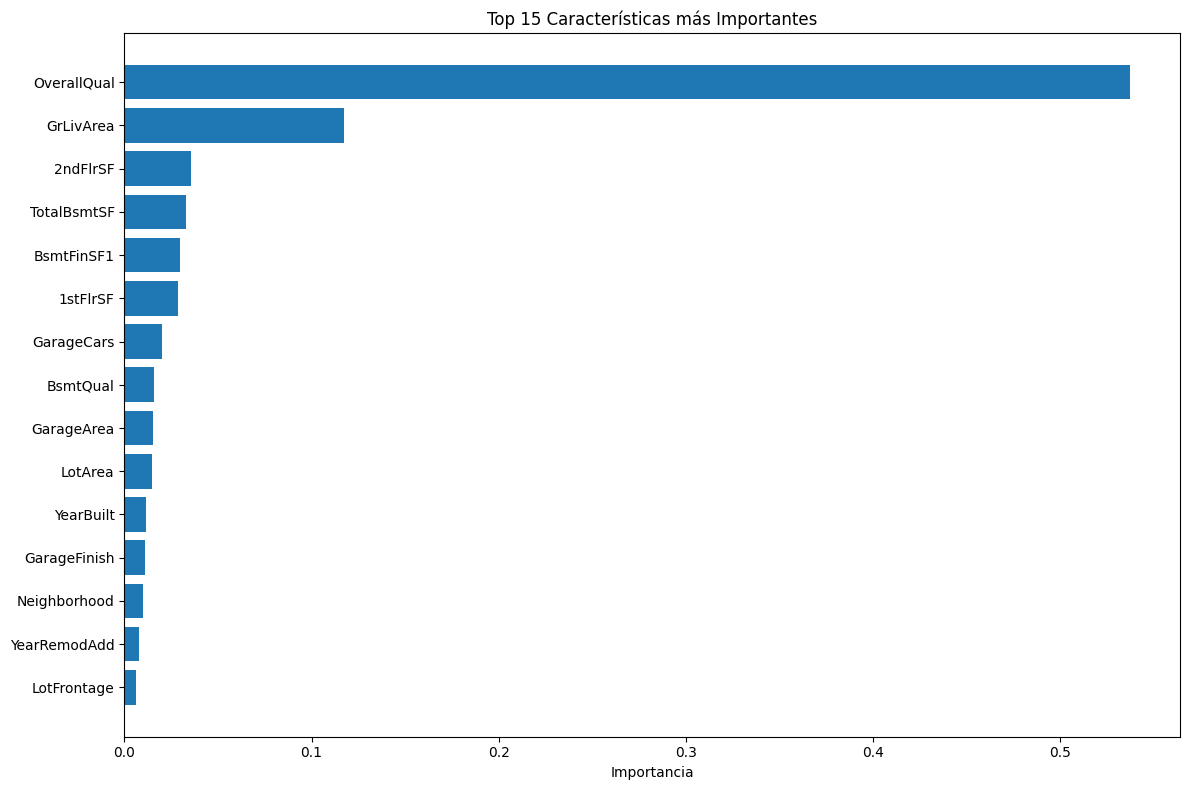


Top 10 características:
        feature  importance
16  OverallQual    0.537196
45    GrLivArea    0.117299
43     2ndFlrSF    0.035387
37  TotalBsmtSF    0.032959
33   BsmtFinSF1    0.029703
42     1stFlrSF    0.028580
60   GarageCars    0.020066
29     BsmtQual    0.015815
61   GarageArea    0.015386
3       LotArea    0.014636


In [16]:
# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 características
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], align='center')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Top 15 Características más Importantes')
plt.tight_layout()
plt.show()

print("\nTop 10 características:")
print(feature_importance.head(10))

## Comparar con Gradient Boosting

In [17]:
# Entrenar Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predicciones
y_pred_gb = gb_model.predict(X_test)

# Métricas
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("=== Gradient Boosting ===")
print(f"R2 Score: {r2_gb:.4f}")
print(f"RMSE: {rmse_gb:,.2f}")

print("\n=== Random Forest ===")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")

=== Gradient Boosting ===
R2 Score: 0.8990
RMSE: 26,547.39

=== Random Forest ===
R2 Score: 0.8973
RMSE: 26,770.07


## Predicciones en datos de prueba


In [ ]:
# Cargar datos de prueba
test_file_path = "test.csv"
test_data = pd.read_csv(test_file_path)
ids = test_data['Id']
test_data = test_data.drop('Id', axis=1)

# Aplicar el mismo preprocesamiento
# Rellenar valores faltantes
for col in numeric_cols:
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(X[col].median())

for col in categorical_cols:
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(X[col].mode()[0])

# Codificar variables categóricas
for col in categorical_cols:
    if col in test_data.columns:
        le = label_encoders[col]
        # Manejar valores unseen
        test_data[col] = test_data[col].apply(
            lambda x: le.transform([str(x)])[0] if str(
                x) in le.classes_ else -1
        )

print(f"Test data shape: {test_data.shape}")

Test data shape: (1459, 79)


In [19]:
# Asegurar que las columnas coincidan
missing_cols = set(X.columns) - set(test_data.columns)
for col in missing_cols:
    test_data[col] = 0

test_data = test_data[X.columns]

# Predicciones
preds = rf_model.predict(test_data)

output = pd.DataFrame({'Id': ids, 'SalePrice': preds})
output.head()

,Id,SalePrice
0,1461,125517.50
1,1462,153187.00
2,1463,183940.00
3,1464,181999.97
4,1465,200068.83


In [20]:
# Guardar submission
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['SalePrice'] = preds
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head()

,Id,SalePrice
0,1461,125517.50
1,1462,153187.00
2,1463,183940.00
3,1464,181999.97
4,1465,200068.83
